In [39]:
import sys
import os
sys.path.append(os.path.abspath("../src"))

import scanpy as sc
from dmt import DyMoTree

adata = sc.read_h5ad("../data/bench/lt/day246/anndata/anndata.h5ad")
#adata = sc.read_h5ad('../data/case/CART/anndata/lineage_tracing2.h5ad')
dmt = DyMoTree(adata=adata,
               k=50,
               progenitor='Undifferentiated',
               terminal=['Neutrophil','Monocyte'],
               lineage_col='Cell.type.annotation',
               emb_key='emb',
               device='cuda',
               seed=907)

dmt.lineage_graph(mask_threshold=0.8, epsilon=1, mode='composite')

Successfully loaded state: Undifferentiated, cells: 1509
Successfully loaded state: Neutrophil, cells: 996
Successfully loaded state: Monocyte, cells: 1004
--- Start Building Lineage Graph ---
[*] Intra-state graph built for 'Undifferentiated' (Edges: 73941)
[*] Intra-state graph built for 'Neutrophil' (Edges: 48804)
[*] Intra-state graph built for 'Monocyte' (Edges: 49196)
[*] Calculating composite similarity between progenitor 'Undifferentiated' and terminals ['Neutrophil', 'Monocyte']...
[*] Inter-state graph built for 'Neutrophil' (Edges: 414452)
[*] Inter-state graph built for 'Monocyte' (Edges: 454401)


In [40]:
dmt.train(pre_train = 'combined',
              lr = {'formal':1e-4,
                    'intra':1e-3,
                    'lineage':1e-4},
              iter = {'formal':300,
                    'intra':100,
                    'lineage':300},
              sample_ratio = 256,
              alpha = 0)

:: Stage1 Pre-training -- intra-state transition graph::
:: Do pre-train Graph encoder for Undifferentiated ::


100%|█████████████████████████████████████████████████| 100/100 [00:07<00:00, 14.07it/s, loss=0.678]


:: Do pre-train Graph encoder for Neutrophil ::


100%|█████████████████████████████████████████████████| 100/100 [00:04<00:00, 21.53it/s, loss=0.679]


:: Do pre-train Graph encoder for Monocyte ::


...

:: Stage2 Pre-training -- lineage-graph::


Iter: 300/300 : 100%|█████████████████████████████████| 300/300 [00:49<00:00,  6.07it/s, loss=0.442]


:: DyMoTree Training::


Iter: 300/300 : 100%|█████████████████████████████████| 300/300 [00:48<00:00,  6.12it/s, loss=0.908]


[2026-04-15 15:19:38] get fate space of Undifferentiated


<Axes: title={'center': 'fate_bias'}, xlabel='plt1', ylabel='plt2'>

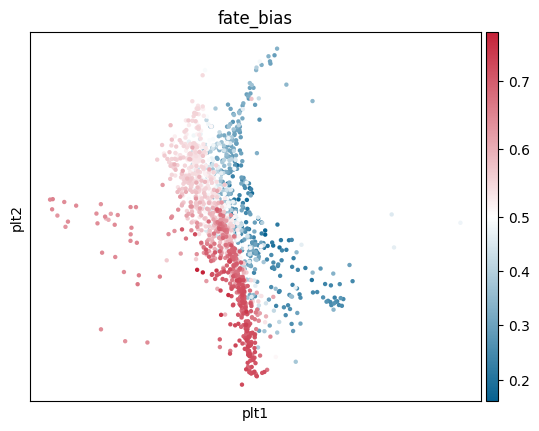

In [41]:
import scanpy as sc
import pandas as pd
import matplotlib.colors as mcolors

custom_bwr = mcolors.LinearSegmentedColormap.from_list(
    "custom_bwr", 
    [(0,"#066190"), (0.5,"white"), (1,"#c42238")]
)


hspc = dmt.treedata.get_node('Undifferentiated',adata_object=True)
hspc.obsm['X_plt'] = hspc.obs.loc[:,['SPRING.x','SPRING.y']].values
hspc.obs['fate_bias'] = dmt.cal_fate_bias(hspc.obs['Neutrophil_fate'], hspc.obs['Monocyte_fate'])
sc.pl.embedding(hspc, basis='plt', color=['fate_bias'], show=False,cmap=custom_bwr,vcenter=0.5,size=40)

In [43]:
sc.pl.embedding(hspc, basis='plt', color=['fate_bias'], show=False,cmap=custom_bwr,vcenter=0.5,size=40,save='LT_fate_bias_visualization.png')

<Axes: title={'center': 'fate_bias'}, xlabel='plt1', ylabel='plt2'>

In [44]:
from utils.metrics import calculate_fate_metrics

truth_fate = hspc.obs['Weinreb_fate'].values
predict_fate = 1-hspc.obs['fate_bias'].values

calculate_fate_metrics(truth_fate, 
                           predict_fate, 
                           threshold = 0.5)

{'auroc': 0.8362500747957635,
 'acc': 0.7746852220013254,
 'f1': 0.7720252102632645,
 'pearson': 0.6025320114364856,
 'spearman': 0.6074498008193058}

In [27]:
import numpy as np
import pandas as pd
from scipy import stats

def gene_obs_correlation(
    adata,
    gene_list,
    obs_key,
    method="pearson",
    layer=None
):
    """
    计算基因表达与obs某一列之间的相关性
    
    参数：
    ----------
    adata : AnnData
    gene_list : list
        基因名列表（必须在 adata.var_names 中）
    obs_key : str
        adata.obs 中的一列（必须为数值型）
    method : str
        "pearson" 或 "spearman"
    layer : str or None
        如果指定，则使用 adata.layers[layer]，否则使用 adata.X
    
    返回：
    ----------
    pd.DataFrame
        包含 gene, correlation, p_value
    """
    
    # 检查 obs 列
    if obs_key not in adata.obs.columns:
        raise ValueError(f"{obs_key} 不在 adata.obs 中")
    
    y = adata.obs[obs_key].values
    
    # 检查是否数值型
    if not np.issubdtype(y.dtype, np.number):
        raise ValueError(f"{obs_key} 必须是数值型")
    
    # 选择表达矩阵
    X = adata.layers[layer] if layer else adata.X
    
    results = []
    
    for gene in gene_list:
        if gene not in adata.var_names:
            results.append((gene, np.nan, np.nan))
            continue
        
        idx = adata.var_names.get_loc(gene)
        x = X[:, idx]
        
        # 稀疏矩阵处理
        if hasattr(x, "toarray"):
            x = x.toarray().flatten()
        else:
            x = np.asarray(x).flatten()
        
        # 计算相关性
        if method == "pearson":
            r, p = stats.pearsonr(x, y)
        elif method == "spearman":
            r, p = stats.spearmanr(x, y)
        else:
            raise ValueError("method 必须是 'pearson' 或 'spearman'")
        
        results.append((gene, r, p))
    
    return pd.DataFrame(results, columns=["gene", "correlation", "p_value"])

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def plot_obs_correlation(
    adata,
    obs_x,
    obs_y,
    method="pearson",
    ci=95,
    color_by=None,
    palette="viridis",
    point_color="steelblue",
    line_color="red",
    figsize=(6, 5),
    scatter_kws=None,
    line_kws=None
):
    """
    绘制 adata.obs 两列之间的相关性散点图 + 拟合曲线 + 相关系数
    
    参数：
    ----------
    adata : AnnData
    obs_x, obs_y : str
        adata.obs 中的两列
    method : str
        "pearson" 或 "spearman"
    ci : int
        回归线置信区间
    color_by : str or None
        用 adata.obs 中另一列给散点上色（连续或分类）
    palette : str
        调色板
    point_color : str
        当 color_by=None 时散点颜色
    line_color : str
        拟合线颜色
    figsize : tuple
    scatter_kws : dict or None
        散点参数
    line_kws : dict or None
        拟合线参数
    
    返回：
    ----------
    fig, ax
    """
    
    # 检查列
    for key in [obs_x, obs_y]:
        if key not in adata.obs.columns:
            raise ValueError(f"{key} 不在 adata.obs 中")
    
    df = adata.obs[[obs_x, obs_y]].copy()
    
    if color_by is not None:
        if color_by not in adata.obs.columns:
            raise ValueError(f"{color_by} 不在 adata.obs 中")
        df[color_by] = adata.obs[color_by]
    
    # 去除缺失值
    drop_cols = [obs_x, obs_y] + ([color_by] if color_by is not None else [])
    df = df.dropna(subset=drop_cols)
    
    x = df[obs_x].values
    y = df[obs_y].values
    
    # 计算相关性
    if method == "pearson":
        r, p = stats.pearsonr(x, y)
    elif method == "spearman":
        r, p = stats.spearmanr(x, y)
    else:
        raise ValueError("method 必须是 'pearson' 或 'spearman'")
    
    # 默认绘图参数
    if scatter_kws is None:
        scatter_kws = {}
    scatter_defaults = {"s": 25, "alpha": 0.7}
    scatter_defaults.update(scatter_kws)
    
    if line_kws is None:
        line_kws = {}
    line_defaults = {"color": line_color, "linewidth": 2}
    line_defaults.update(line_kws)
    
    # 作图
    fig, ax = plt.subplots(figsize=figsize)
    
    if color_by is None:
        ax.scatter(x, y, color=point_color, **scatter_defaults)
    else:
        c = df[color_by]
        if pd.api.types.is_numeric_dtype(c):
            sc = ax.scatter(x, y, c=c.values, cmap=palette, **scatter_defaults)
            cbar = fig.colorbar(sc, ax=ax)
            cbar.set_label(color_by)
        else:
            c = c.astype("category")
            categories = c.cat.categories
            colors = sns.color_palette(palette, len(categories))
            color_map = dict(zip(categories, colors))
            for cat in categories:
                idx = c == cat
                ax.scatter(x[idx], y[idx], color=color_map[cat], label=str(cat), **scatter_defaults)
            ax.legend(title=color_by, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 拟合回归线
    sns.regplot(x=x, y=y, scatter=False, ci=ci, line_kws=line_defaults, ax=ax)
    
    # 标注相关性
    text = f"{method.capitalize()} r = {r:.3f}\np = {p:.2e}"
    ax.text(0.05, 0.95, text, transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3",
                                              facecolor="white", alpha=0.7, edgecolor="none"))
    
    ax.set_xlabel(obs_x)
    ax.set_ylabel(obs_y)
    ax.set_title(f"{obs_x} vs {obs_y}")
    plt.tight_layout()
    
    return fig, ax

(<Figure size 600x500 with 2 Axes>,
 <Axes: title={'center': 'Monocyte_fate vs Neutrophil_fate'}, xlabel='Monocyte_fate', ylabel='Neutrophil_fate'>)

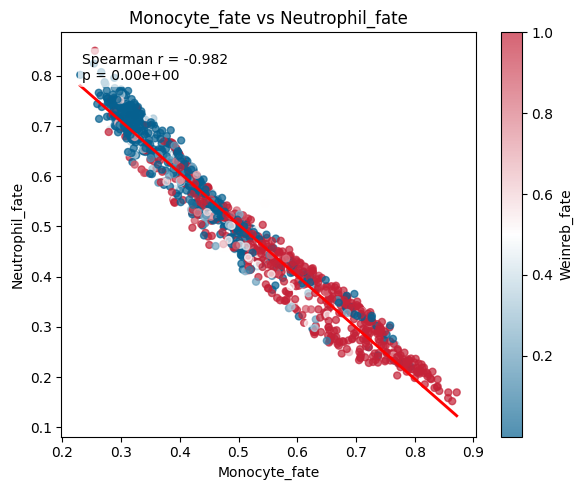

In [29]:
import scanpy as sc
import pandas as pd
import matplotlib.colors as mcolors

custom_bwr = mcolors.LinearSegmentedColormap.from_list(
    "custom_bwr", 
    [(0,"#066190"), (0.5,"white"), (1,"#c42238")]
)
plot_obs_correlation(hspc, "Monocyte_fate", "Neutrophil_fate", color_by="Weinreb_fate", palette=custom_bwr,method='spearman')


(<Figure size 600x500 with 2 Axes>,
 <Axes: title={'center': 'Monocyte_propensity vs Neutrophil_propensity'}, xlabel='Monocyte_propensity', ylabel='Neutrophil_propensity'>)

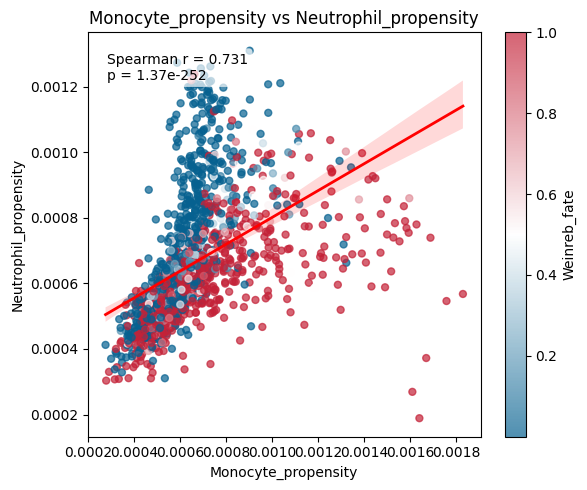

In [38]:
plot_obs_correlation(hspc, "Monocyte_propensity", "Neutrophil_propensity", color_by="Weinreb_fate", palette=custom_bwr,method='spearman')

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, sparse


def plot_feature_correlation(
    adata,
    x_key,
    y_key,
    method="pearson",
    ci=95,
    color_by=None,
    palette="viridis",
    point_color="steelblue",
    line_color="red",
    figsize=None,
    scatter_kws=None,
    line_kws=None,
    layer=None,
    use_raw=False,
    ncols=3,
    sharex=False,
    sharey=False
):
    """
    Plot correlation scatter between two features.

    Supported combinations:
    1. str vs str
    2. list vs str
    3. str vs list

    A feature can be:
    - a column in adata.obs
    - a gene name

    Parameters
    ----------
    adata : AnnData
    x_key : str or list[str]
    y_key : str or list[str]
    method : str
        "pearson" or "spearman"
    ci : int or None
        Confidence interval for regression line
    color_by : str or None
        Column name in adata.obs used for coloring points
    palette : str
        Colormap or palette name
    point_color : str
        Point color when color_by is None
    line_color : str
        Regression line color
    figsize : tuple or None
        Figure size; auto-calculated for multi-panel plots if None
    scatter_kws : dict or None
        Extra kwargs for scatter
    line_kws : dict or None
        Extra kwargs for regression line
    layer : str or None
        Use adata.layers[layer] if provided
    use_raw : bool
        Use adata.raw.X if True
    ncols : int
        Number of columns for multi-panel plots
    sharex : bool
    sharey : bool

    Returns
    -------
    result_df : pandas.DataFrame
    fig : matplotlib.figure.Figure
    axes : matplotlib.axes.Axes or np.ndarray
    """

    def _get_matrix_and_var_names():
        if use_raw:
            if adata.raw is None:
                raise ValueError("use_raw=True but adata.raw is None")
            return adata.raw.X, adata.raw.var_names
        if layer is not None:
            if layer not in adata.layers:
                raise ValueError(f"Layer '{layer}' not found in adata.layers")
            return adata.layers[layer], adata.var_names
        return adata.X, adata.var_names

    def _extract_vector(key):
        if key in adata.obs.columns:
            values = adata.obs[key].values
            return values, "obs", key

        X, var_names = _get_matrix_and_var_names()
        if key in var_names:
            idx = var_names.get_loc(key)
            values = X[:, idx]
            if sparse.issparse(values):
                values = values.toarray().ravel()
            else:
                values = np.asarray(values).ravel()
            return values, "gene", key

        raise ValueError(f"'{key}' not found in adata.obs.columns or gene names")

    def _plot_single(ax, x_name, y_name):
        x, x_type, x_label = _extract_vector(x_name)
        y, y_type, y_label = _extract_vector(y_name)

        df = pd.DataFrame({"x": x, "y": y})

        if color_by is not None:
            if color_by not in adata.obs.columns:
                raise ValueError(f"'{color_by}' not found in adata.obs.columns")
            df[color_by] = adata.obs[color_by].values
            drop_cols = ["x", "y", color_by]
        else:
            drop_cols = ["x", "y"]

        df = df.dropna(subset=drop_cols)

        x = df["x"].values
        y = df["y"].values

        if not pd.api.types.is_numeric_dtype(x):
            raise ValueError(f"'{x_name}' is not numeric")
        if not pd.api.types.is_numeric_dtype(y):
            raise ValueError(f"'{y_name}' is not numeric")

        if len(df) < 3:
            r, p = np.nan, np.nan
        else:
            if method == "pearson":
                r, p = stats.pearsonr(x, y)
            elif method == "spearman":
                r, p = stats.spearmanr(x, y)
            else:
                raise ValueError("method must be 'pearson' or 'spearman'")

        local_scatter_kws = {"s": 25, "alpha": 0.7}
        if scatter_kws is not None:
            local_scatter_kws.update(scatter_kws)

        local_line_kws = {"color": line_color, "linewidth": 2}
        if line_kws is not None:
            local_line_kws.update(line_kws)

        if color_by is None:
            ax.scatter(x, y, color=point_color, **local_scatter_kws)
        else:
            c = df[color_by]
            if pd.api.types.is_numeric_dtype(c):
                sc = ax.scatter(x, y, c=c.values, cmap=palette, **local_scatter_kws)
                return_colorbar = sc
            else:
                return_colorbar = None
                c = c.astype("category")
                categories = c.cat.categories
                colors = sns.color_palette(palette, len(categories))
                color_map = dict(zip(categories, colors))
                for cat in categories:
                    idx = c == cat
                    ax.scatter(
                        x[idx],
                        y[idx],
                        color=color_map[cat],
                        label=str(cat),
                        **local_scatter_kws
                    )
                ax.legend(title=color_by, bbox_to_anchor=(1.05, 1), loc="upper left")

        sns.regplot(
            x=x,
            y=y,
            scatter=False,
            ci=ci,
            line_kws=local_line_kws,
            ax=ax
        )

        text = f"{method.capitalize()} r = {r:.3f}\np = {p:.2e}"
        ax.text(
            0.05,
            0.95,
            text,
            transform=ax.transAxes,
            va="top",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="white",
                alpha=0.7,
                edgecolor="none"
            )
        )

        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.set_title(f"{x_label} vs {y_label}")

        stats_row = {
            "x": x_label,
            "y": y_label,
            "x_type": x_type,
            "y_type": y_type,
            "method": method,
            "correlation": r,
            "p_value": p,
            "n": len(df)
        }

        return stats_row, locals().get("return_colorbar", None)

    x_is_list = isinstance(x_key, (list, tuple, np.ndarray, pd.Index))
    y_is_list = isinstance(y_key, (list, tuple, np.ndarray, pd.Index))

    if x_is_list and y_is_list:
        raise ValueError("Only one of x_key and y_key can be a list")

    if not x_is_list and not y_is_list:
        if figsize is None:
            figsize = (6, 5)
        fig, ax = plt.subplots(figsize=figsize)
        stats_row, colorbar_obj = _plot_single(ax, x_key, y_key)
        if color_by is not None and colorbar_obj is not None:
            cbar = fig.colorbar(colorbar_obj, ax=ax)
            cbar.set_label(color_by)
        plt.tight_layout()
        result_df = pd.DataFrame([stats_row])
        return result_df, fig, ax

    if x_is_list:
        feature_list = list(x_key)
        fixed_key = y_key
        plot_pairs = [(feature, fixed_key) for feature in feature_list]
    else:
        feature_list = list(y_key)
        fixed_key = x_key
        plot_pairs = [(fixed_key, feature) for feature in feature_list]

    n_plots = len(plot_pairs)
    if n_plots == 0:
        raise ValueError("Feature list is empty")

    nrows = int(np.ceil(n_plots / ncols))
    if figsize is None:
        figsize = (4.5 * ncols, 4.0 * nrows)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        sharex=sharex,
        sharey=sharey
    )

    if isinstance(axes, np.ndarray):
        axes_flat = axes.ravel()
    else:
        axes_flat = np.array([axes])

    results = []
    colorbar_obj = None

    for i, (x_name, y_name) in enumerate(plot_pairs):
        stats_row, cb_obj = _plot_single(axes_flat[i], x_name, y_name)
        results.append(stats_row)
        if color_by is not None and colorbar_obj is None and cb_obj is not None:
            colorbar_obj = cb_obj

    for j in range(n_plots, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    if color_by is not None and colorbar_obj is not None:
        used_axes = axes_flat[:n_plots].tolist()
        cbar = fig.colorbar(colorbar_obj, ax=used_axes)
        cbar.set_label(color_by)

    plt.tight_layout()
    result_df = pd.DataFrame(results)
    return result_df, fig, axes

/tmp/ipykernel_2455167/459032760.py:278: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


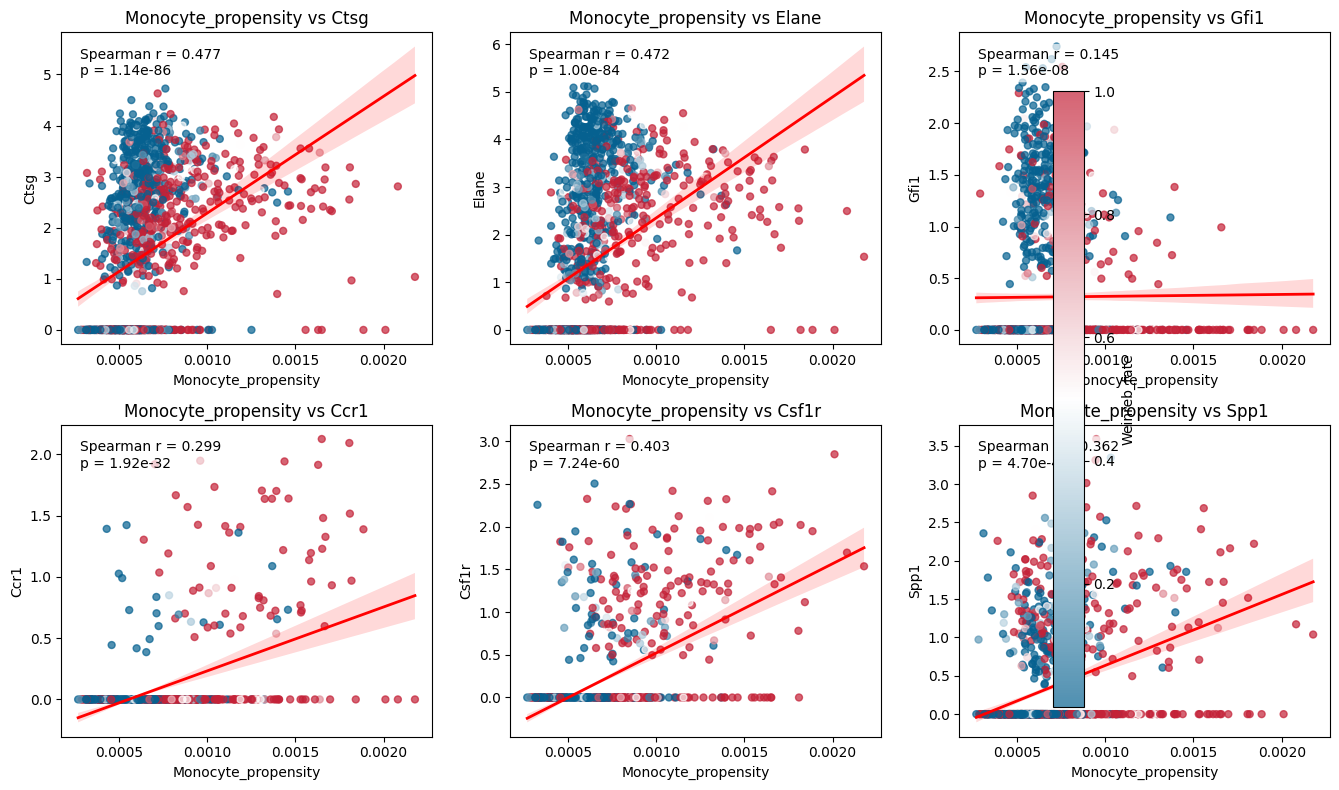

In [63]:
result_df, fig, axes = plot_feature_correlation(
    hspc,
    x_key="Monocyte_propensity",
    y_key=["Ctsg", "Elane", "Gfi1","Ccr1","Csf1r",'Spp1'],
    method="spearman",
    color_by="Weinreb_fate", palette=custom_bwr,
    ncols=3
)
plt.savefig("../experiment/LT.nonlinearly.compare.prior.mono.png",bbox_inches='tight')

/tmp/ipykernel_2455167/459032760.py:278: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


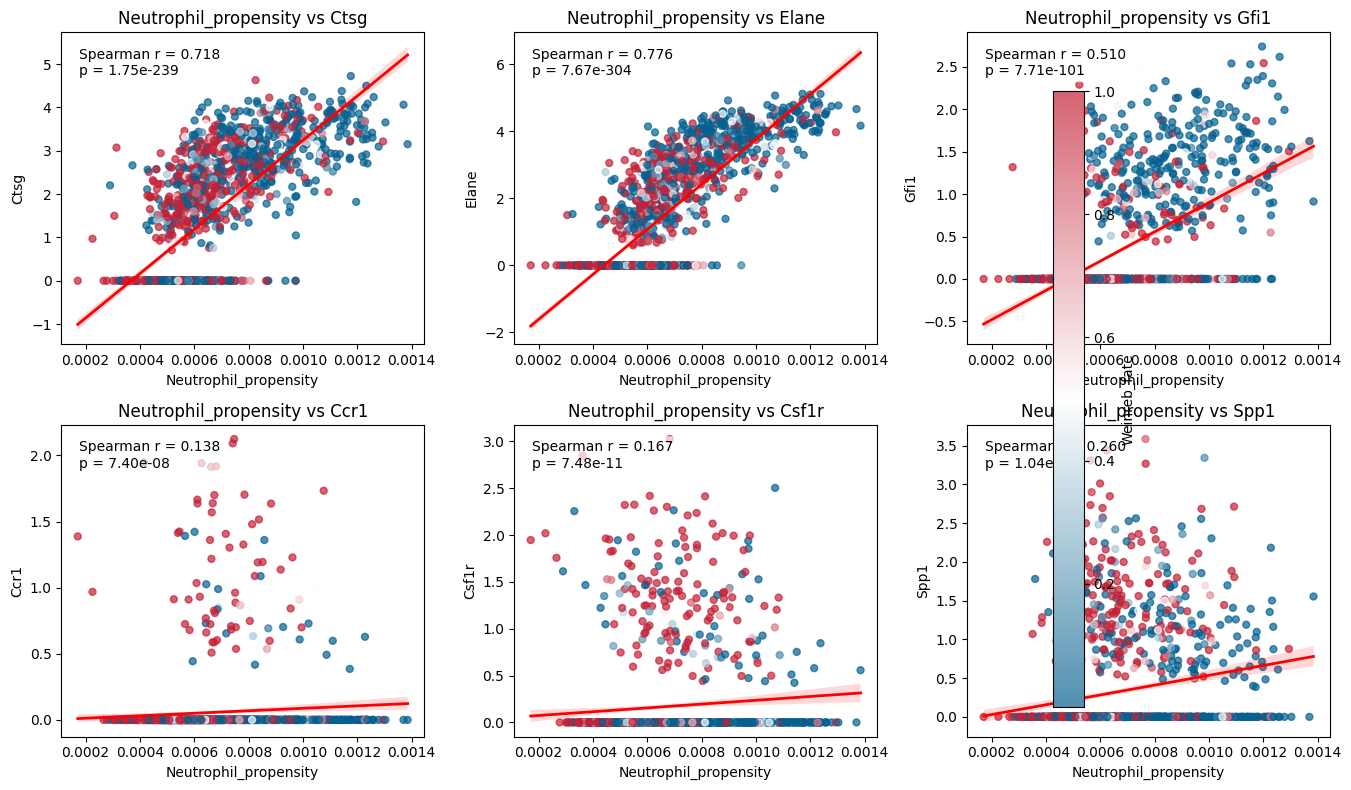

In [65]:
result_df, fig, axes = plot_feature_correlation(
    hspc,
    x_key="Neutrophil_propensity",
    y_key=["Ctsg", "Elane", "Gfi1","Ccr1","Csf1r",'Spp1'],
    method="spearman",
    color_by="Weinreb_fate", palette=custom_bwr,
    ncols=3
)
plt.savefig("../experiment/LT.nonlinearly.compare.prior.neu.pdf",bbox_inches='tight')

/tmp/ipykernel_2455167/459032760.py:278: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


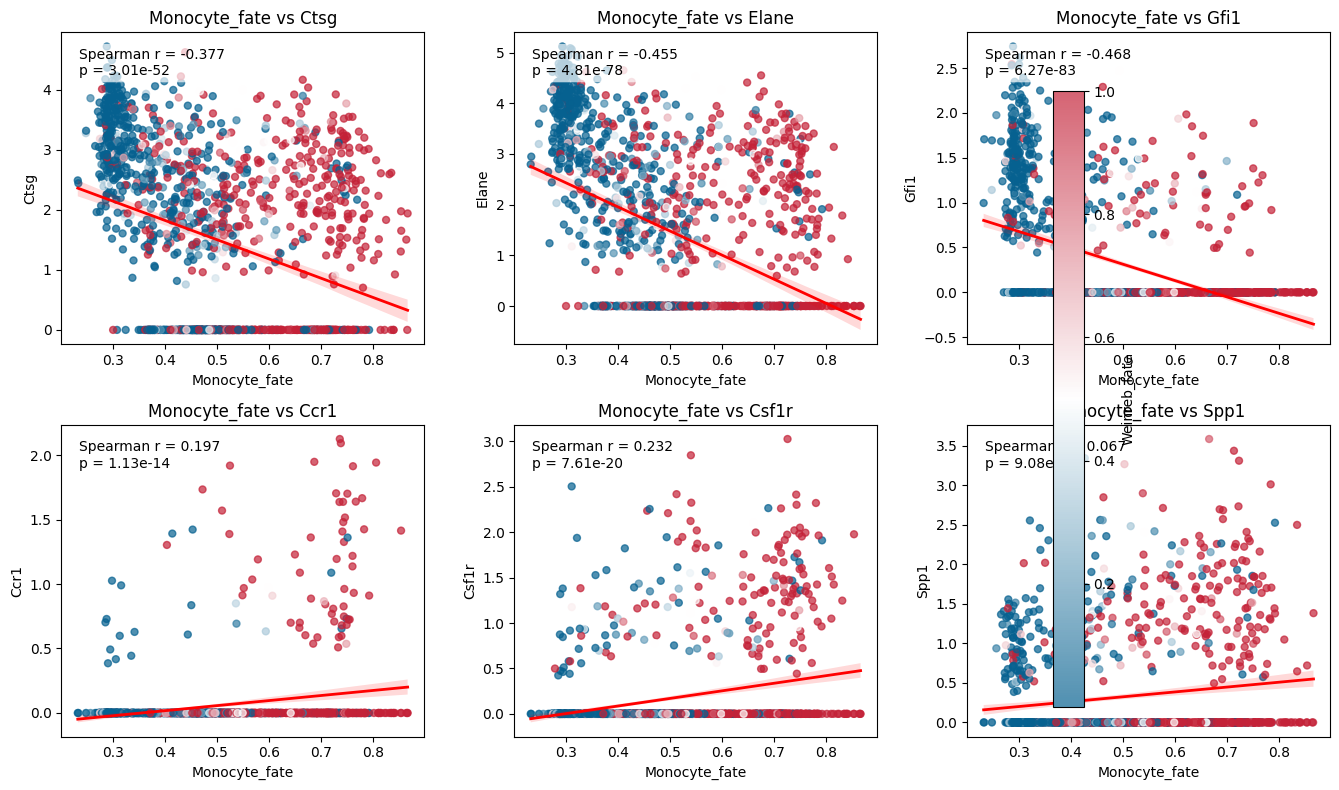

In [67]:
result_df, fig, axes = plot_feature_correlation(
    hspc,
    x_key="Monocyte_fate",
    y_key=["Ctsg", "Elane", "Gfi1","Ccr1","Csf1r",'Spp1'],
    method="spearman",
    color_by="Weinreb_fate", palette=custom_bwr,
    ncols=3
)
plt.savefig("../experiment/LT.nonlinearly.compare.model.mono.pdf",bbox_inches='tight')

/tmp/ipykernel_2455167/459032760.py:278: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


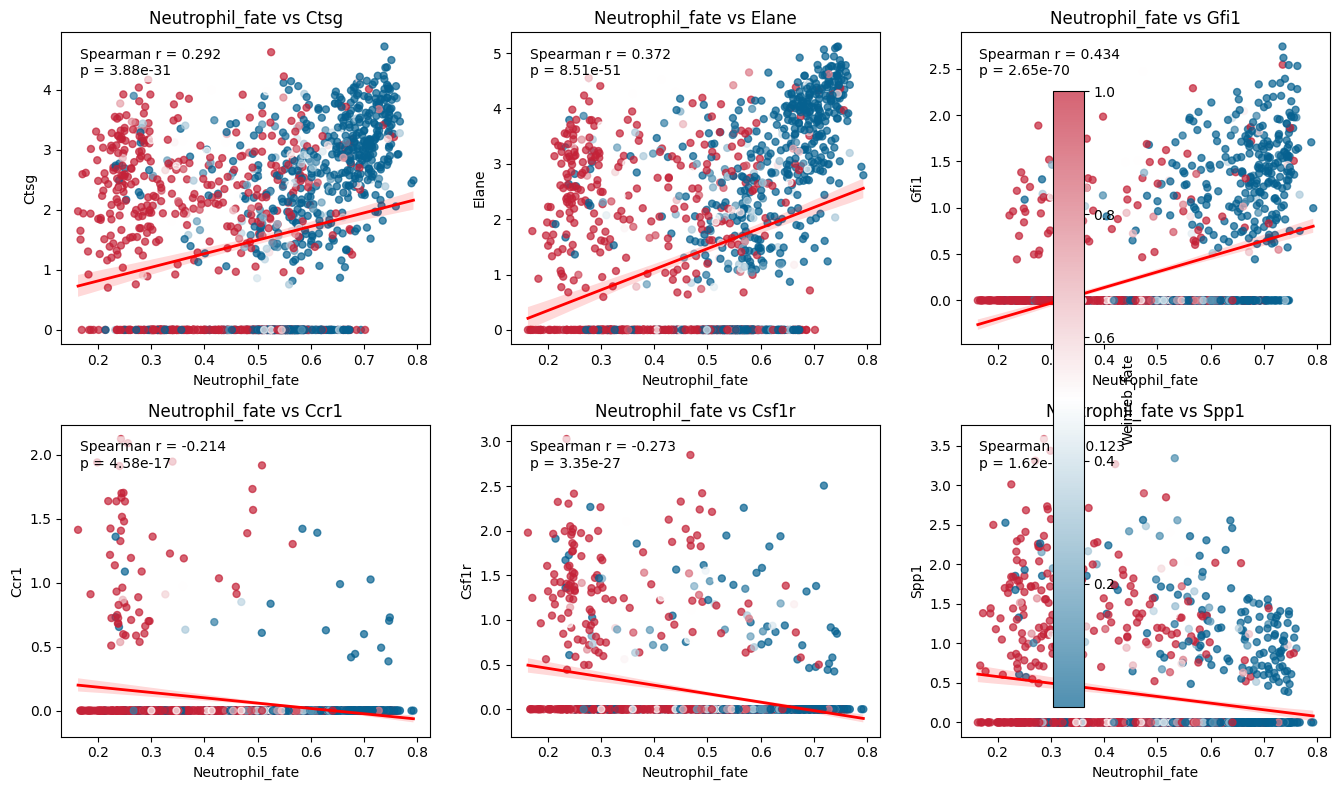

In [69]:
result_df, fig, axes = plot_feature_correlation(
    hspc,
    x_key="Neutrophil_fate",
    y_key=["Ctsg", "Elane", "Gfi1","Ccr1","Csf1r",'Spp1'],
    method="spearman",
    color_by="Weinreb_fate", palette=custom_bwr,
    ncols=3
)
plt.savefig("../experiment/LT.nonlinearly.compare.model.neu.png",bbox_inches='tight')

In [58]:
import random
import sys
import os
from utils.metrics import calculate_fate_metrics
import scanpy as sc
from dmt import DyMoTree

sys.path.append(os.path.abspath("../src"))

adata = sc.read_h5ad("../data/bench/lt/day246/anndata/lineage_tracing2.h5ad")
#adata = sc.read_h5ad('../data/case/CART/anndata/lineage_tracing2.h5ad')



r = 0
run = 20
metric = pd.DataFrame(columns=['AUROC','Accuracy','F1-score','Pearson','Spearman'])
seeds = [392,375,426,192,410,474,426,628,488,808,777,289,306,1019,532,891,556,824,125,976]
for i in seeds:
      dmt = DyMoTree(adata=adata,
               k=50,
               progenitor='Undifferentiated',
               terminal=['Neutrophil','Monocyte'],
               lineage_col='Cell.type.annotation',
               emb_key='emb',
               device='cuda',
               seed=i)

      dmt.lineage_graph(mask_threshold=0.8, epsilon=1, mode='composite')
      dmt.train(pre_train = 'combined',
              lr = {'formal':1e-4,
                    'intra':1e-3,
                    'lineage':1e-4},
              iter = {'formal':300,
                    'intra':100,
                    'lineage':300},
              sample_ratio = 256,
              alpha = 0)
      hspc = dmt.treedata.get_node('Undifferentiated',adata_object=True)
      hspc.obs['fate_bias'] = dmt.cal_fate_bias(hspc.obs['Neutrophil_fate'], hspc.obs['Monocyte_fate'])


      truth_fate = hspc.obs['Weinreb_fate'].values
      predict_fate = 1-hspc.obs['fate_bias'].values

      metric.loc[r] = calculate_fate_metrics(truth_fate, 
                           predict_fate, 
                           threshold = 0.5)
      r+=1
      
metric.to_csv('./Fig2.1.Larry.DMT.bench.result.performance.csv')

Successfully loaded state: Undifferentiated, cells: 1509
Successfully loaded state: Neutrophil, cells: 996
Successfully loaded state: Monocyte, cells: 1004
--- Start Building Lineage Graph ---
[*] Intra-state graph built for 'Undifferentiated' (Edges: 73941)
[*] Intra-state graph built for 'Neutrophil' (Edges: 48804)
[*] Intra-state graph built for 'Monocyte' (Edges: 49196)
[*] Calculating composite similarity between progenitor 'Undifferentiated' and terminals ['Neutrophil', 'Monocyte']...
[*] Inter-state graph built for 'Neutrophil' (Edges: 335347)
[*] Inter-state graph built for 'Monocyte' (Edges: 409595)
:: Stage1 Pre-training -- intra-state transition graph::
:: Do pre-train Graph encoder for Undifferentiated ::


100%|█████████████████████████████████████████████████| 100/100 [00:07<00:00, 14.07it/s, loss=0.776]


:: Do pre-train Graph encoder for Neutrophil ::


100%|█████████████████████████████████████████████████| 100/100 [00:04<00:00, 20.78it/s, loss=0.794]


:: Do pre-train Graph encoder for Monocyte ::


...

:: Stage2 Pre-training -- lineage-graph::


Iter: 300/300 : 100%|█████████████████████████████████| 300/300 [01:22<00:00,  3.65it/s, loss=0.557]


:: DyMoTree Training::


Iter: 300/300 : 100%|██████████████████████████████████| 300/300 [01:17<00:00,  3.87it/s, loss=1.03]

[2026-04-07 18:48:07] get fate space of Undifferentiated


In [78]:
# find cell state
dmt.find_state(n_state=3,
               n_pca=5,
               n_diff=5,
               n_gene=20,
               method='spearman')

[2026-04-15 15:46:26] find cell state of Undifferentiated
[2026-04-15 15:46:26] Filtering Data by fate space


/home/wangjiayi/.conda/envs/dymotree/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


[2026-04-15 15:46:29] PCA transformation
[2026-04-15 15:46:30] Run Diffusion map
[2026-04-15 15:46:31] Find archetypes


<Axes: title={'center': 'Fate_State'}, xlabel='plt1', ylabel='plt2'>

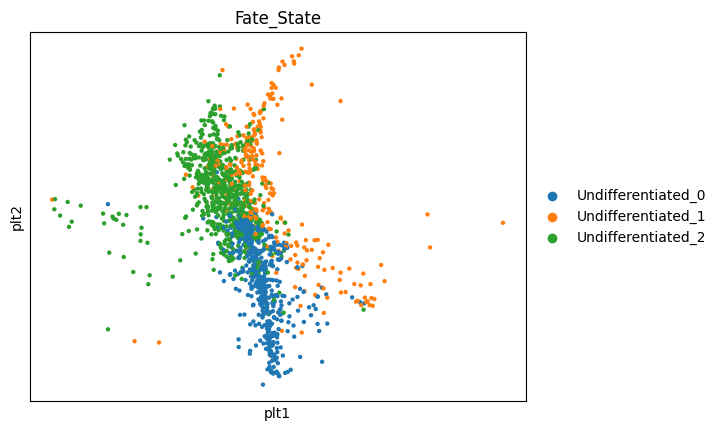

In [79]:
hspc = dmt.treedata.get_node('Undifferentiated',adata_object=True)
hspc.obsm['X_spring'] = hspc.obs.loc[:,['SPRING.x','SPRING.y']].values
hspc.obs['fate_bias'] = dmt.cal_fate_bias(hspc.obs['Neutrophil_fate'], hspc.obs['Monocyte_fate'])
sc.pl.embedding(hspc, basis='plt', color=['Fate_State'], show=False,cmap='bwr',vcenter=0.5,size=40)

In [81]:
import pandas as pd

hspc.obs.to_csv('../notebooks/Fig2/1.Larry.DMT.bench.result/Larry.day246.result.metadata.csv')